<a href="https://colab.research.google.com/github/hima1222/Machine_Learning_Mini_Project/blob/main/Machine_Learning_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets -q
import opendatasets as od

od.download("https://www.kaggle.com/datasets/mansoordaku/ckdisease")



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: chandimasandamali
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mansoordaku/ckdisease


100%|██████████| 9.51k/9.51k [00:00<00:00, 6.53MB/s]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df = pd.read_csv('/content/ckdisease/kidney_disease.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset Shape: (400, 26)

Columns:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [ ]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:

df.isnull().sum()


,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


##Preprocessing

In [ ]:
# remove hidden spaces in column names
df.columns = df.columns.str.strip()


In [ ]:
# replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# remove whitespace inside string cells
df=df.apply(lambda x: x.str.strip() if x.dtype== "object" else x)

In [ ]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)


In [ ]:
for col in['pcv', 'wc', 'rc']:
  if col in df.columns:
    df[col]=pd.to_numeric(df[col],errors='coerce')


In [ ]:
print(df[['pcv', 'wc', 'rc']].dtypes)
print(df[['pcv', 'wc', 'rc']].isnull().sum())

pcv    float64
wc     float64
rc     float64
dtype: object
pcv     71
wc     106
rc     131
dtype: int64


In [ ]:
df['classification'] = df['classification'].astype(str).str.strip()

y = df['classification']
X = df.drop('classification', axis=1)

# convert target to binary
y = y.map({'ckd': 1, 'notckd': 0})

print("Target values:", y.unique())
print("Missing in target:", y.isnull().sum())


Target values: [1 0]
Missing in target: 0


## Handling missing values


In [ ]:
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# Numerical columns into median
num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Categorical columns into most frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])


Encoding categorical variables

In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X.shape)


Shape after encoding: (400, 24)


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (320, 24)
Test shape: (80, 24)


Dataset Balancing

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")


Scaling complete.


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_resampled)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)


## RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train_resampled)

# Predictions
y_pred_rf = rf.predict(X_test_scaled)


In [ ]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr, X_train_scaled, y_train_resampled, cv=5)
cv_rf = cross_val_score(rf, X_train_scaled, y_train_resampled, cv=5)

print("Logistic Regression CV Mean Accuracy:", cv_lr.mean())
print("Random Forest CV Mean Accuracy:", cv_rf.mean())

Logistic Regression CV Mean Accuracy: 0.99
Random Forest CV Mean Accuracy: 0.9925


##Confusion Matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Logistic Regression ===
Accuracy: 0.9875
[[30  0]
 [ 1 49]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


=== Random Forest ===
Accuracy: 1.0
[[30  0]
 [ 0 50]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



##Important Features

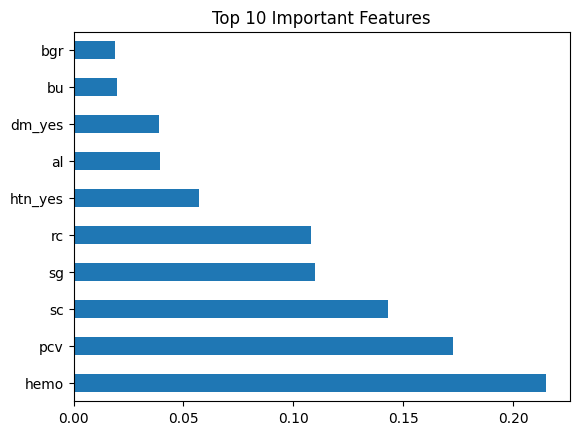

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

##Comparison of Logistic Regression and Random Forest

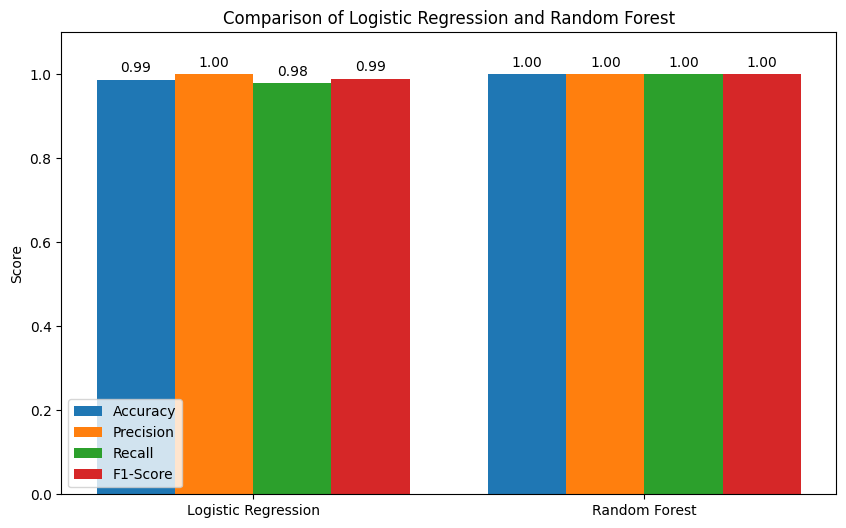

In [ ]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = ['Logistic Regression', 'Random Forest']

# Logistic Regression metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Random Forest metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Store values
accuracy = [accuracy_lr, accuracy_rf]
precision = [precision_lr, precision_rf]
recall = [recall_lr, recall_rf]
f1_scores = [f1_lr, f1_rf]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - 1.5*width, accuracy, width, label='Accuracy')
rects2 = ax.bar(x - 0.5*width, precision, width, label='Precision')
rects3 = ax.bar(x + 0.5*width, recall, width, label='Recall')
rects4 = ax.bar(x + 1.5*width, f1_scores, width, label='F1-Score')

ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Comparison of Logistic Regression and Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center',
                    va='bottom')

for rects in [rects1, rects2, rects3, rects4]:
    autolabel(rects)

plt.show()

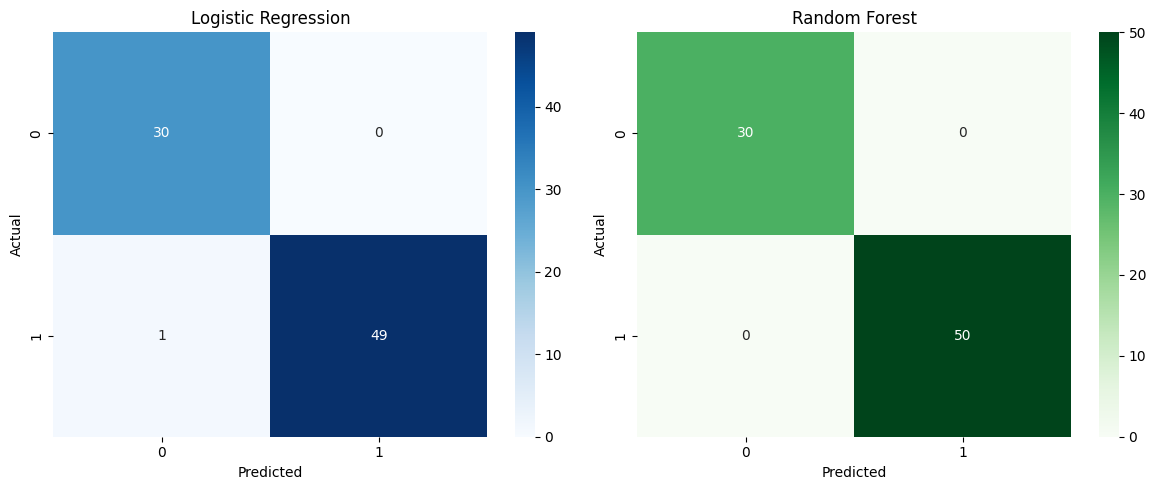

In [ ]:

from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression heatmap
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Comparrison of Accuracy


/tmp/ipykernel_895/408924898.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=metrics, palette=['blue', 'green'])


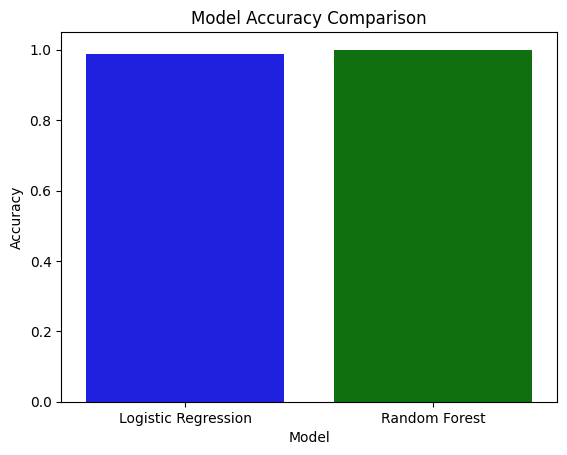

In [ ]:

metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)]
})

sns.barplot(x='Model', y='Accuracy', data=metrics, palette=['blue', 'green'])
plt.ylim(0, 1.05)
plt.title('Model Accuracy Comparison')
plt.show()